In [31]:
import pandas as pd
import geodatasets
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from mpl_toolkits.basemap import Basemap


In [32]:
df_estaciones = pd.read_csv('../data/estaciones.csv', sep=",", header=0)
df_estaciones.head()

,CODIGO,DESCRIPCION,LATITUD,LONGITUD,DIRECION,CP,POBLACION,PROVINCIA,PAIS,CERCANIAS,FEVE,COMUN
0,1003.0,ARAHAL,37.268081,-5.548514,"C/ Virgen de los Dolores, S/N",41600,ARAHAL,SEVILLA,ESPAÑA,NO,NO,NaN
1,1005.0,MARCHENA,37.334282,-5.425519,"Avda. Maestro Santos Rúano, 8",41620,MARCHENA,SEVILLA,ESPAÑA,NO,NO,NaN
2,1007.0,OSUNA,37.233899,-5.115026,"Avda. Estación Ferrocarril, S/N",41640,OSUNA,SEVILLA,ESPAÑA,NO,NO,NaN
3,1009.0,PEDRERA,37.222396,-4.893519,"C/ Manuel Aranda, 3",41566,PEDRERA,SEVILLA,ESPAÑA,NO,NO,NaN
4,2002.0,PUENTE GENIL-HERRERA,37.357900,-4.821638,Ctra. A-318 - Km. 9 - Entre los Pueblos de Pue...,14500,PUENTE GENIL,CÓRDOBA,ESPAÑA,NO,NO,PTE G


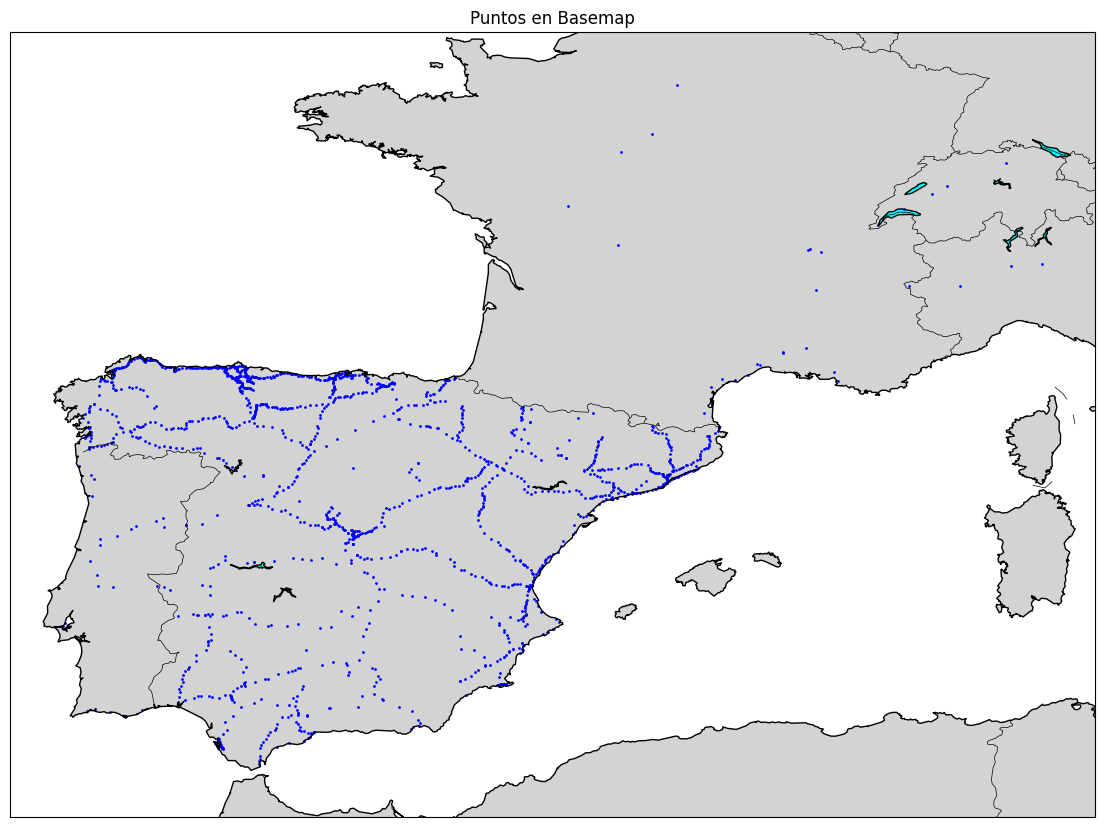

In [ ]:
lat_t = 31.268081
lon_t = -5.548514

# Calcular los límites del dataset + un margen (padding)
margin = 1
lat_min, lat_max = df_estaciones['LATITUD'].min() - margin, df_estaciones['LATITUD'].max() + margin
lon_min, lon_max = df_estaciones['LONGITUD'].min() - margin, df_estaciones['LONGITUD'].max() + margin

fig = plt.figure(figsize=(14, 14))

m = Basemap(
    projection='cyl',
    resolution='i',
    llcrnrlat=lat_min,
    urcrnrlat=lat_max,
    llcrnrlon=lon_min,
    urcrnrlon=lon_max,
)

# Dibujar elementos del mapa
m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='lightgray', lake_color='aqua')

# Transformar lat/lon a coordenadas x/y del mapa
x, y = m(df_estaciones['LONGITUD'], df_estaciones['LATITUD'])

# Dibujar el punto
m.scatter(x, y, color='blue', marker='o', s=1)
plt.title("Puntos en Basemap")
plt.show()

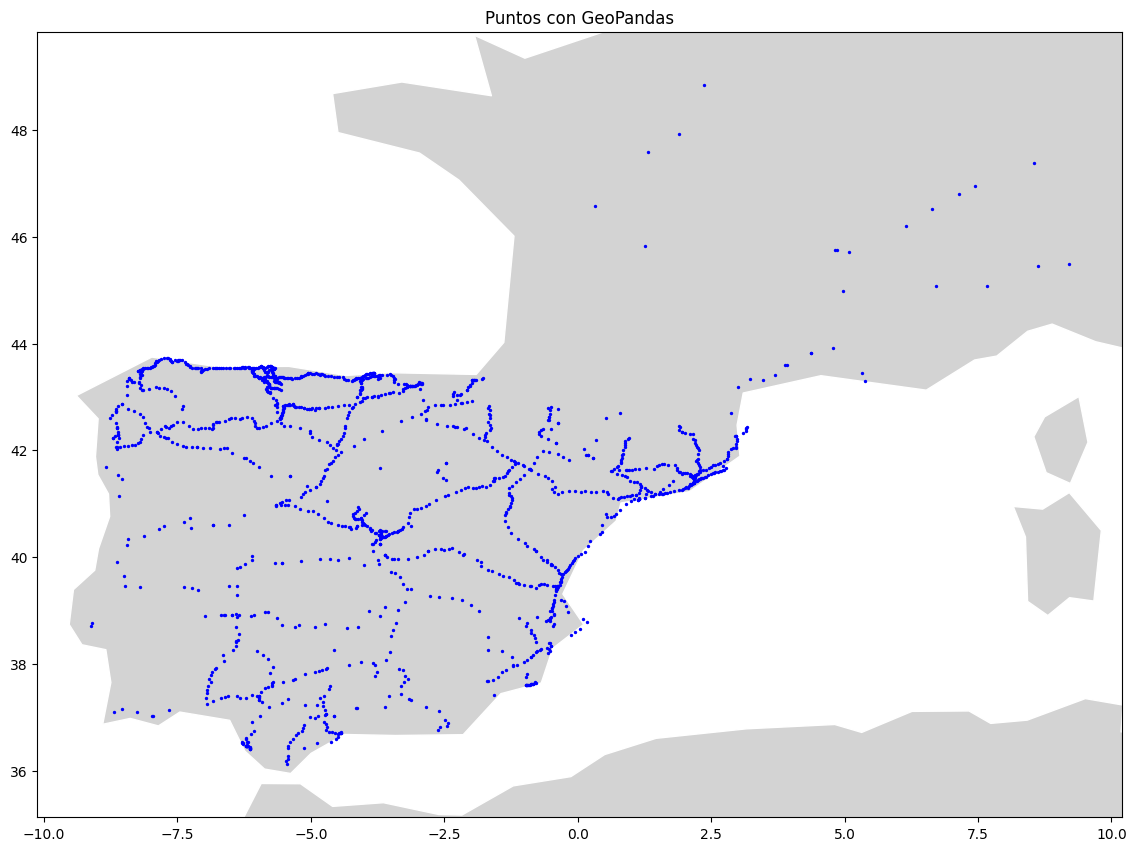

In [48]:
# 1. Datos de ejemplo
data = {'Ciudad': df_estaciones['DESCRIPCION'],
        'Lat': df_estaciones['LATITUD'],
        'Lon': df_estaciones['LONGITUD']}

# 2. Crear GeoDataFrame convirtiendo Lat/Lon a puntos geométricos
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['Lon'], data['Lat']))

# 3. Cargar un mapa del mundo incluido en la librería
path = geodatasets.get_path("naturalearth.land")
world = gpd.read_file(path)

# 4. Graficar el mapa base y los puntos encima
ax = world.plot(color='lightgrey', edgecolor='white', figsize=(14, 14))
gdf.plot(ax=ax, color='blue', markersize=2)

# 5. Zoom a los puntos (con margen de 5 grados)
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx - 1, maxx + 1)
ax.set_ylim(miny - 1, maxy + 1)

plt.title('Puntos con GeoPandas')
plt.show()